In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import napari
from skimage.transform import radon, resize
from skimage.transform import iradon, iradon_sart
from skimage.metrics import structural_similarity as ssim
from scipy.optimize import curve_fit
from functions import (  # self defined (somewhat)
    generate_num_projections,
    generate_sparse_sinogram,
    order_angles_golden_ratio,
    modified_sart_plus_tv,
)
from skimage.data import shepp_logan_phantom
from skimage import io

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# torus image code, used in lots of cells

# R value is radius of larger circle
big_r = 4

# r value is radius of smaller circle
r = 2

x_vals = np.linspace(-7, 7, 200)
y_vals = np.linspace(-7, 7, 200)
z_vals = np.linspace(
    -7, 7, 200
)  # can change number of 'layers' of 2D images to simuate number of slices taken
i, j, k = np.meshgrid(x_vals, y_vals, z_vals)

# create 3d intensity array
torus_image = (np.sqrt((np.sqrt(i**2 + j**2) - big_r) ** 2 + k**2) < r).astype(
    float
)  # astype(float) evaluates boolean expresion with 1 or 0

# Torus generation

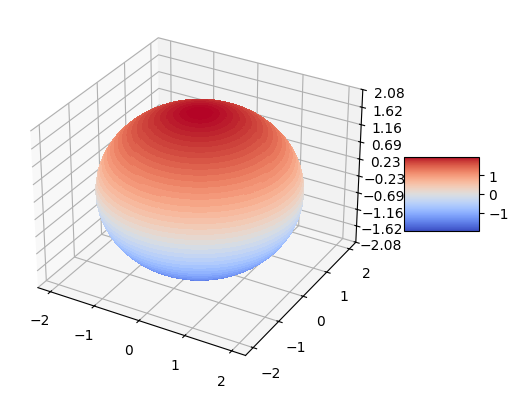

In [3]:
# R value is radius of larger circle
large_r = 5

# r value is radius of smaller circle
r = 2

x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
i, j = np.meshgrid(x_vals, y_vals)

phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, np.pi, 100)
PHI, THETA = np.meshgrid(phi, theta)
X = r * np.sin(THETA) * np.cos(PHI)
Y = r * np.sin(THETA) * np.sin(PHI)
Z = r * np.cos(THETA)

# Generate graph
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter("{x:.02f}")

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=1)

plt.show()

In [ ]:
x_vals = np.linspace(-5, 5, 1000)
y_vals = np.linspace(-5, 5, 1000)
z_vals = np.linspace(-5, 5, 1000)
i, j, k = np.meshgrid(x_vals, y_vals, z_vals)
sphere_image = (np.sqrt(i**2 + j**2 + k**2) < r).astype(
    float
)  # astype(float) evaluates boolean expresion with 1 or 0

viewer = napari.Viewer()
viewer.add_image(sphere_image, name="sphere_image")
napari.run()

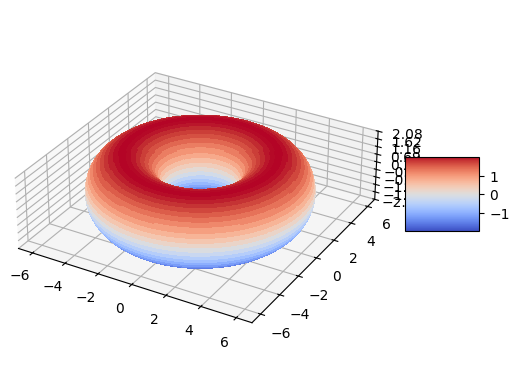

In [ ]:
# R value is radius of larger circle
big_r = 4

# r value is radius of smaller circle
r = 2

x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
i, j = np.meshgrid(x_vals, y_vals)

phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, 2 * np.pi, 100)
PHI, THETA = np.meshgrid(phi, theta)
X = (big_r + r * np.sin(THETA)) * np.cos(PHI)
Y = (big_r + r * np.sin(THETA)) * np.sin(PHI)
Z = r * np.cos(THETA)

# Generate graph
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
# This is usfeful for visualisation, but really we have just supplied the points along the surface of the torus.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter("{x:.02f}")

# set equal aspect ratio
ax.set_aspect("equal")

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=1)

plt.show()

In [ ]:
x_vals = np.linspace(-7, 7, 200)
y_vals = np.linspace(-7, 7, 200)
z_vals = np.linspace(
    -7, 7, 200
)  # can change number of 'layers' of 2D images to simuate number of slices taken
i, j, k = np.meshgrid(x_vals, y_vals, z_vals)

# create 3d intensity array
torus_image = (np.sqrt((np.sqrt(i**2 + j**2) - big_r) ** 2 + k**2) < r).astype(
    float
)  # astype(float) evaluates boolean expresion with 1 or 0

viewer = napari.Viewer()
viewer.add_image(torus_image, name="torus_image")
napari.run()

libEGL warning: failed to get driver name for fd -1

libEGL warning: MESA-LOADER: failed to retrieve device information

libEGL warning: failed to get driver name for fd -1

MESA: error: ZINK: failed to choose pdev
libEGL warning: egl: failed to create dri2 screen


# Discussion of sinograms 
Constructed from 2d intensity slices through object. 3D image reconstructed from the stacking of reconstructed 2d mages. These 2D images are reconstructed using different methods to inverse the sinogram

The Fourier Slice Theorem says:

The 1D Fourier transform of a projection equals a slice through the 2D Fourier transform of the image.

This is the key tomography theorem.

Expand on this above statement. (AI written so need to rewrite).

When reconstructing, the fourier slice theorem is basically taking the intensity projections at different angles, and for each angle it is converting the intensity distribution into a frequency distribution. All of thse fourier slices need to be combined and then the inverse found to reconstruct the image. the way the slices are combined depends on the algorithm?

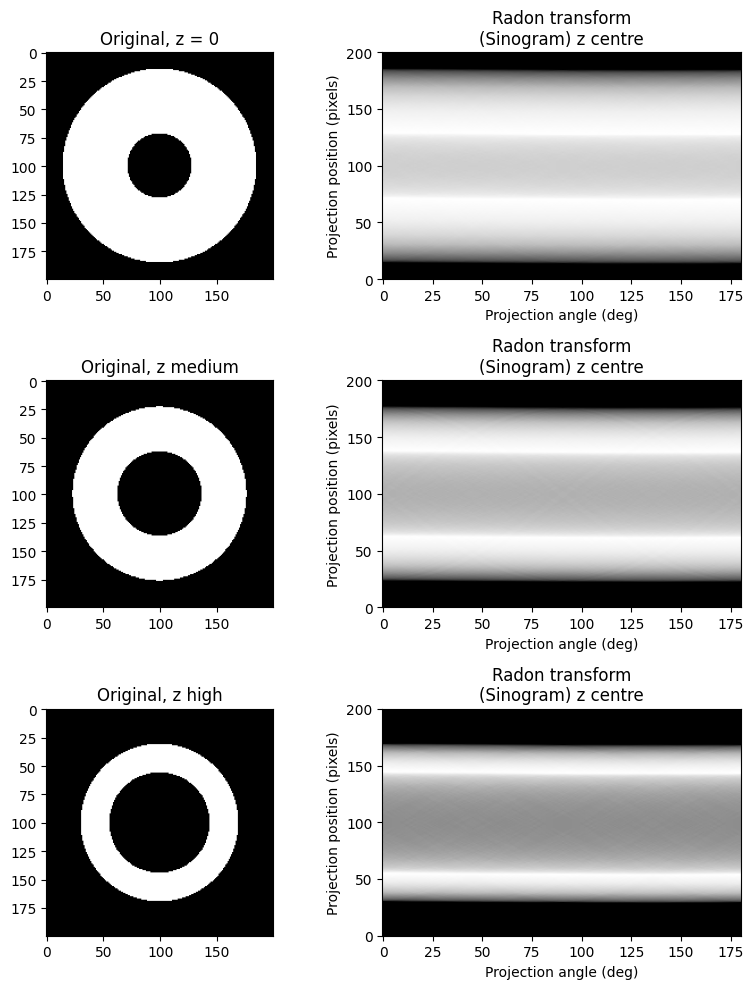

In [ ]:
# Using the radon trasnform. We will start off with a full 180 degree scan of the torus, creating a detailed sinogram

# Use central slice of torus along x-y plane with z = 0
image1 = torus_image[:, :, 100]
image2 = torus_image[:, :, 120]
image3 = torus_image[:, :, 125]
# image = rescale(image, scale=0.2, mode='reflect', channel_axis=None)

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(8, 10))

ax1.set_title("Original, z = 0")
ax1.imshow(image1, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image1.shape), endpoint=False)
# Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image1, theta=theta)
dx, dy = 0.5 * 180.0 / max(image1.shape), 0.5 / sinogram.shape[0]
ax2.set_title("Radon transform\n(Sinogram) z centre")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect="auto",
)

ax3.set_title("Original, z medium")
ax3.imshow(image2, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image2.shape), endpoint=False)
# Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image2, theta=theta)
dx, dy = 0.5 * 180.0 / max(image2.shape), 0.5 / sinogram.shape[0]
ax4.set_title("Radon transform\n(Sinogram) z centre")
ax4.set_xlabel("Projection angle (deg)")
ax4.set_ylabel("Projection position (pixels)")
ax4.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect="auto",
)


ax5.set_title("Original, z high")
ax5.imshow(image3, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image3.shape), endpoint=False)
# Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image3, theta=theta)
dx, dy = 0.5 * 180.0 / max(image3.shape), 0.5 / sinogram.shape[0]
ax6.set_title("Radon transform\n(Sinogram) z centre")
ax6.set_xlabel("Projection angle (deg)")
ax6.set_ylabel("Projection position (pixels)")
ax6.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect="auto",
)

fig.tight_layout()
plt.show()

# How errors arise in FBP
Hard to compute inverse radon transform, the algorithms are approximations of the true inverse. There are also errors due to the rotation of the immage arrays and the interpolation used to fit rotated values tointeger grid points.

FBP rms reconstruction error: 0.0387


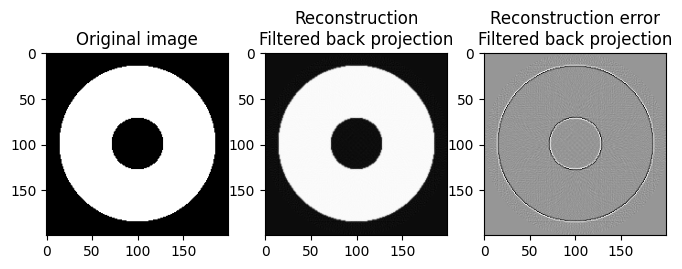

In [ ]:
# Displaying reconstructed image along with error -code modified from  scikit-image radon function examples
image = torus_image[:, :, 100]
sinogram = radon(image, theta=theta)

reconstruction_fbp = iradon(sinogram, theta=theta, filter_name="ramp")
error = reconstruction_fbp - image
print(f"FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}")

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4.5))
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
ax2.set_title("Reconstruction\nFiltered back projection")
ax2.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax3.set_title("Reconstruction error\nFiltered back projection")
ax3.imshow(reconstruction_fbp - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()

SART (1 iteration) rms reconstruction error: 0.0453
SART (2 iterations) rms reconstruction error: 0.0377
SART (10 iterations) rms reconstruction error: 0.0293


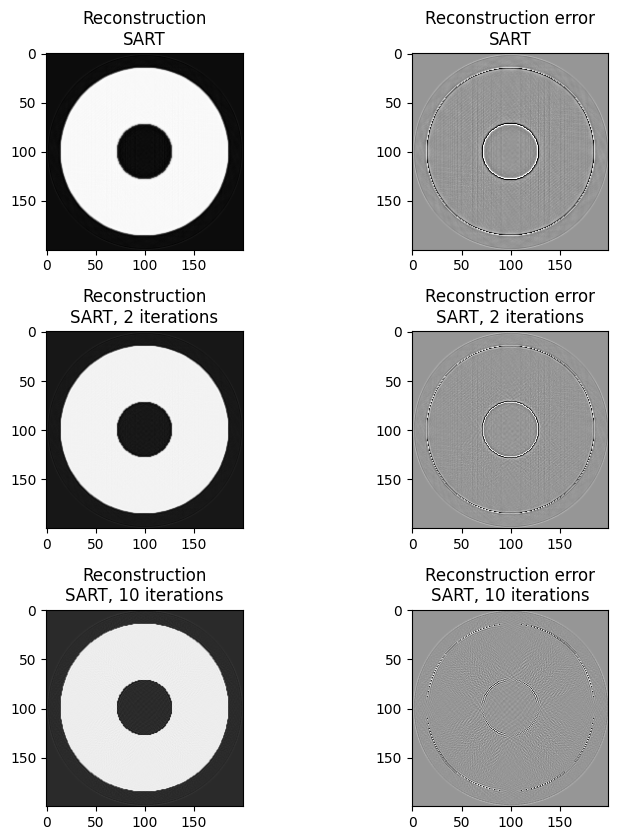

In [ ]:
# Code from scikit image radon examples
image = torus_image[:, :, 100]
sinogram = radon(image, theta=theta)

reconstruction_sart = iradon_sart(sinogram, theta=theta)
error = reconstruction_sart - image
print(
    f"SART (1 iteration) rms reconstruction error: " f"{np.sqrt(np.mean(error**2)):.3g}"
)

fig, axes = plt.subplots(3, 2, figsize=(8, 8.5))
ax = axes.ravel()

ax[0].set_title("Reconstruction\nSART")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nSART")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart)
error = reconstruction_sart2 - image
print(
    f"SART (2 iterations) rms reconstruction error: "
    f"{np.sqrt(np.mean(error**2)):.3g}"
)

ax[2].set_title("Reconstruction\nSART, 2 iterations")
ax[2].imshow(reconstruction_sart2, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nSART, 2 iterations")
ax[3].imshow(reconstruction_sart2 - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a tenth iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart_n = reconstruction_sart
for i in range(9):
    reconstruction_sart_n = iradon_sart(
        sinogram, theta=theta, image=reconstruction_sart_n
    )

error = reconstruction_sart_n - image
print(
    f"SART (10 iterations) rms reconstruction error: "
    f"{np.sqrt(np.mean(error**2)):.3g}"
)

ax[4].set_title("Reconstruction\nSART, 10 iterations")
ax[4].imshow(reconstruction_sart_n, cmap=plt.cm.Greys_r)

ax[5].set_title("Reconstruction error\nSART, 10 iterations")
ax[5].imshow(reconstruction_sart_n - image, cmap=plt.cm.Greys_r, **imkwargs)

fig.tight_layout()
plt.show()

# Reconstruct sparse sinogram using inverse reconstruction techniques

Notice that SART error increases as it starts fitting artefacts. Mention this

FBP MSE reconstruction error: 0.19
FBP SSIM reconstruction error: 0.216


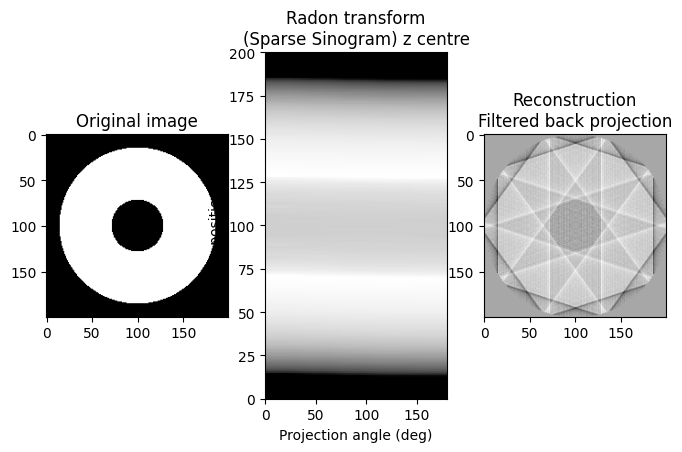

SART (1 iteration) rms reconstruction error: 0.266
SART (2 iterations) rms reconstruction error: 0.181
SART (10 iterations) rms reconstruction error: 0.125


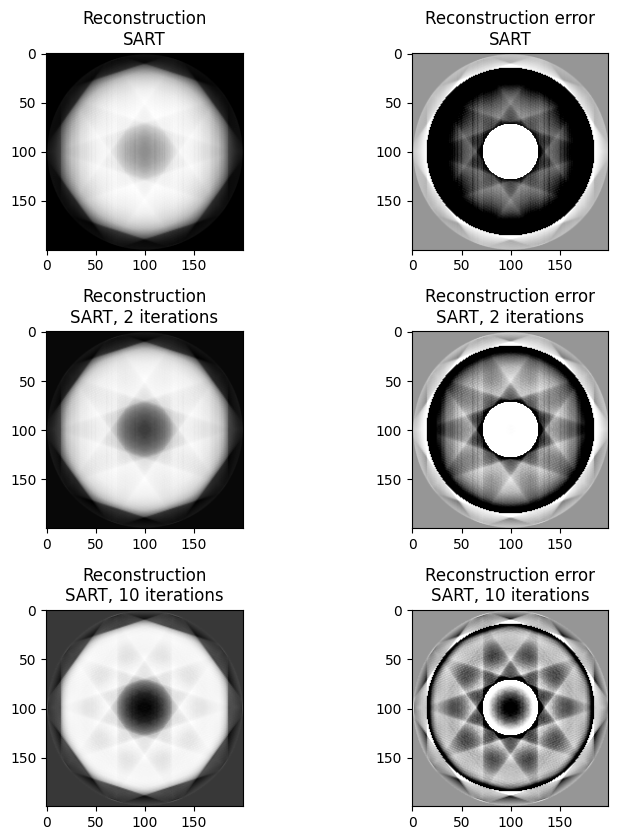

In [ ]:
theta_sparse = np.linspace(0, 180, 5, endpoint=False)
sparse_sinogram = radon(image, theta=theta_sparse)

reconstruction_fbp = iradon(sparse_sinogram, theta=theta_sparse, filter_name="ramp")
error = reconstruction_fbp - image
print(f"FBP MSE reconstruction error: {np.mean(error**2):.3g}")
print(
    f"FBP SSIM reconstruction error: {ssim(image, reconstruction_fbp, data_range = np.max(image)-np.min(image)):.3g}"
)

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4.5))
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sparse_sinogram.shape[0]
ax2.set_title("Radon transform\n(Sparse Sinogram) z centre")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sparse_sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sparse_sinogram.shape[0] + dy),
    aspect="auto",
)
ax3.set_title("Reconstruction\nFiltered back projection")
ax3.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
plt.show()

reconstruction_sart = iradon_sart(sparse_sinogram, theta=theta_sparse)
error = reconstruction_sart - image
print(
    f"SART (1 iteration) rms reconstruction error: " f"{np.sqrt(np.mean(error**2)):.3g}"
)

fig, axes = plt.subplots(3, 2, figsize=(8, 8.5))
ax = axes.ravel()

ax[0].set_title("Reconstruction\nSART")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nSART")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(
    sparse_sinogram, theta=theta_sparse, image=reconstruction_sart
)
error = reconstruction_sart2 - image
print(
    f"SART (2 iterations) rms reconstruction error: "
    f"{np.sqrt(np.mean(error**2)):.3g}"
)

ax[2].set_title("Reconstruction\nSART, 2 iterations")
ax[2].imshow(reconstruction_sart2, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nSART, 2 iterations")
ax[3].imshow(reconstruction_sart2 - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a tenth iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart_n = reconstruction_sart
for i in range(9):
    reconstruction_sart_n = iradon_sart(
        sparse_sinogram, theta=theta_sparse, image=reconstruction_sart_n
    )

error = reconstruction_sart_n - image
print(
    f"SART (10 iterations) rms reconstruction error: "
    f"{np.sqrt(np.mean(error**2)):.3g}"
)

ax[4].set_title("Reconstruction\nSART, 10 iterations")
ax[4].imshow(reconstruction_sart_n, cmap=plt.cm.Greys_r)

ax[5].set_title("Reconstruction error\nSART, 10 iterations")
ax[5].imshow(reconstruction_sart_n - image, cmap=plt.cm.Greys_r, **imkwargs)

fig.tight_layout()
plt.show()

# Comparison of errors between FBP, SART and SART + TV denoising

First calculate MSE error, simple to do but is not always indicative of the perceived similarity between images that may be mathematically similar. This method calulates total difference in pixel intensities of two images, by subtracting the intensity values of matching pixels for every pixel in the image. The resulting 'error' is squared, and the mean calculated. Note that units of MSE are squared units of intensity, and root mean squared error (RMSE) may provide a better perceived visualisation of image error.

Another way of comparing images is the Structural Similarity Index, or SSIM. This takes texture into account, and will be calculated using scikit-image's ssim function. It is a perception based method of calculating image similarity, whereas MSE is not perception based. Evidence shows that SSIM may align more closely with the way that we perceive differences in images.


Both errors are measured, for 3 recomstructive techniques, Filtered Back Projection, SART and a modified SART wth additional Total Variation (TV) denoising. This is implemented again using scikit-image's TV filter. Errors were calculated for a range of images, with increasingly fewer angles. This simulates a constricted lab environment where due to experimental constraints, only limited intensity distributions can be collected. Limited angle topography is characterised by incomplete sinograms. The problem of reconstructing an accurate image becomes more difficult, as there is less initial data.

In [6]:
image = torus_image[:, :, 100]
print(image.shape)
image = shepp_logan_phantom()
print(image.shape)

(200, 200)
(400, 400)


/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
/tmp/ipykernel_170673/2501268350.py:61: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/2501268350.py:72: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/2501268350.py:83: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/2501268350.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argu

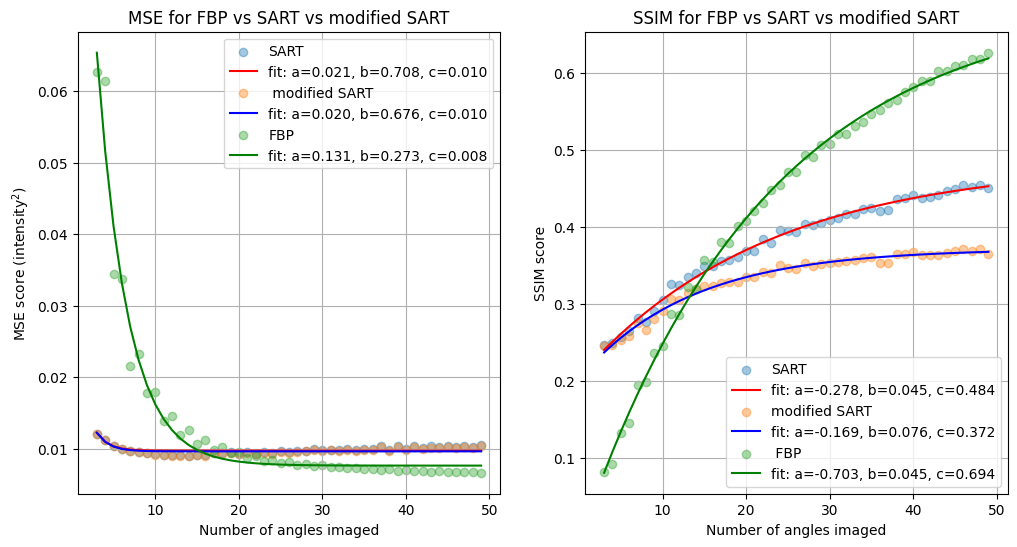

In [ ]:
num_projections = generate_num_projections(10)


def calculate_mse(original_image, reconstructed_image):
    return np.mean((original_image - reconstructed_image) ** 2)


def calculate_ssim(original_image, reconstructed_image):
    return ssim(
        original_image,
        reconstructed_image,
        data_range=original_image.max() - original_image.min(),
    )  # NOTE: Does data range vary between original and reconstrcted images?


# NOTE different images, clean this up

image = torus_image[:, :, 100]
image = shepp_logan_phantom()
# downsampling shepp logan phantom image
image = resize(image, (image.shape[0] // 2, image.shape[1] // 2), anti_aliasing=True)
image = io.imread("images/cells.tif")[32, :, :]
# downsampling cells image
image = resize(image, (image.shape[0] // 2, image.shape[1] // 2), anti_aliasing=True)

num_desired_slices = np.arange(3, 50, step=1)
mse_fbp = []
ssim_fbp = []
mse_sart = []
ssim_sart = []
mse_modified_sart = []
ssim_modified_sart = []
for i in num_desired_slices:
    sparse_sinogram = generate_sparse_sinogram(image, i)
    reconstruction_fbp = iradon(sparse_sinogram)
    mse_fbp.append(calculate_mse(image, reconstruction_fbp))
    ssim_fbp.append(calculate_ssim(image, reconstruction_fbp))
    reconstruction_sart = iradon_sart(sparse_sinogram)
    mse_sart.append(calculate_mse(image, reconstruction_sart))
    ssim_sart.append(calculate_ssim(image, reconstruction_sart))
    reconstruction_modified_sart = modified_sart_plus_tv(sparse_sinogram, weight=0.01)
    mse_modified_sart.append(calculate_mse(image, reconstruction_modified_sart))
    ssim_modified_sart.append(calculate_ssim(image, reconstruction_modified_sart))


# curve fitting with expontential function
def func(x, a, b, c):
    return a * np.exp(-b * x) + c


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.set_title("MSE for FBP vs SART vs modified SART")
ax1.set_xlabel("Number of angles imaged")
ax1.set_ylabel("MSE score (intensity$^2$)")
ax1.grid()

# plot SART MSE vals
ax1.scatter(num_desired_slices, mse_sart, label="SART", alpha=0.4)

popt, pcov = curve_fit(func, num_desired_slices, mse_sart, p0=[1, 0.5, 0])
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="red",
)

# plot modified SART MSE vals
ax1.scatter(num_desired_slices, mse_modified_sart, label=" modified SART", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, mse_modified_sart, p0=[1, 0.5, 0])
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="blue",
)

# plot FBP MSE vals
ax1.scatter(num_desired_slices, mse_fbp, label="FBP", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, mse_fbp, p0=[1, 0.5, 0])
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="green",
)

ax2.set_title("SSIM for FBP vs SART vs modified SART")
ax2.set_xlabel("Number of angles imaged")
ax2.set_ylabel("SSIM score")
ax2.grid()

# plot SART SSIM vals
ax2.scatter(num_desired_slices, ssim_sart, label="SART", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, ssim_sart, p0=[-1, 0.5, 1])
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="red",
)

# plot modified SART SSIM vals
ax2.scatter(num_desired_slices, ssim_modified_sart, label="modified SART", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, ssim_modified_sart, p0=[-1, 0.5, 1])
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="blue",
)

ax2.scatter(num_desired_slices, ssim_fbp, label=" FBP", alpha=0.4)

popt, pcov = curve_fit(func, num_desired_slices, ssim_fbp, p0=[-1, 0.5, 1])
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="green",
)

ax1.legend()
ax2.legend()
plt.show()

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


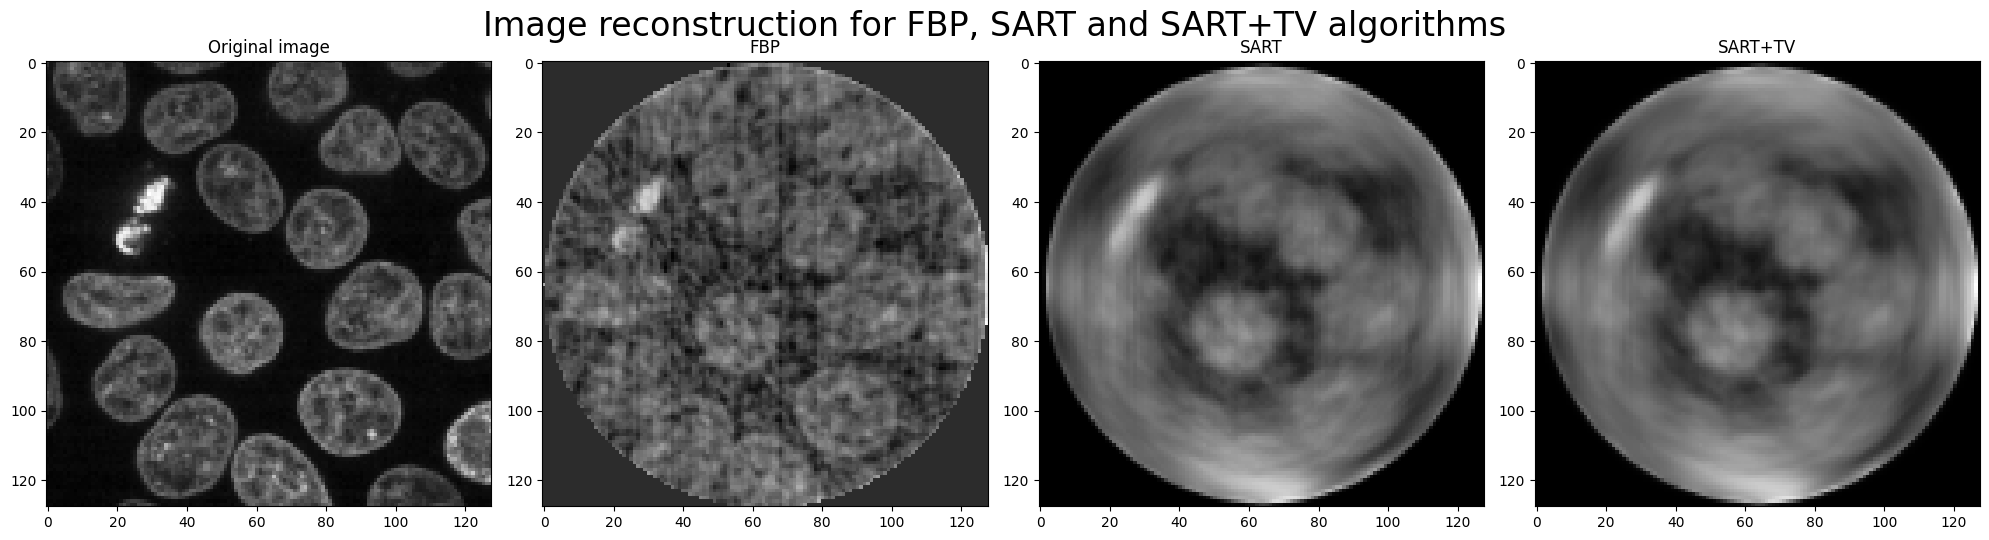

In [ ]:
image = io.imread("images/cells.tif")[32, :, :]
# downsampling cells image
image = resize(image, (image.shape[0] // 2, image.shape[1] // 2), anti_aliasing=True)
# example of bad naming. There are two different types of projections, an integer passed into generate_sparse_sinogram and an array of projections that needs to be passed into sart functions.
projection_array = generate_num_projections(15)

sparse_sinogram = generate_sparse_sinogram(image, 15)


reconstruction_modified_sart = modified_sart_plus_tv(
    sparse_sinogram, theta=projection_array, weight=0.001
)

reconstruction_fbp = iradon(sparse_sinogram, theta=projection_array, filter_name="ramp")

reconstruction_sart = iradon_sart(sparse_sinogram, theta=projection_array)

# imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10))

fig.suptitle(
    "Image reconstruction for FBP, SART and SART+TV algorithms",
    y=0.75,
    fontsize=24,
)
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
ax2.set_title("FBP")
ax2.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax3.set_title("SART")
ax3.imshow(reconstruction_sart, cmap=plt.cm.Greys_r)
ax4.set_title("SART+TV")
ax4.imshow(reconstruction_modified_sart, cmap=plt.cm.Greys_r)

fig.tight_layout()
plt.show()

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
/tmp/ipykernel_170673/3549304302.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/3549304302.py:62: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/3549304302.py:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(
/tmp/ipykernel_170673/3549304302.py:89: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argu

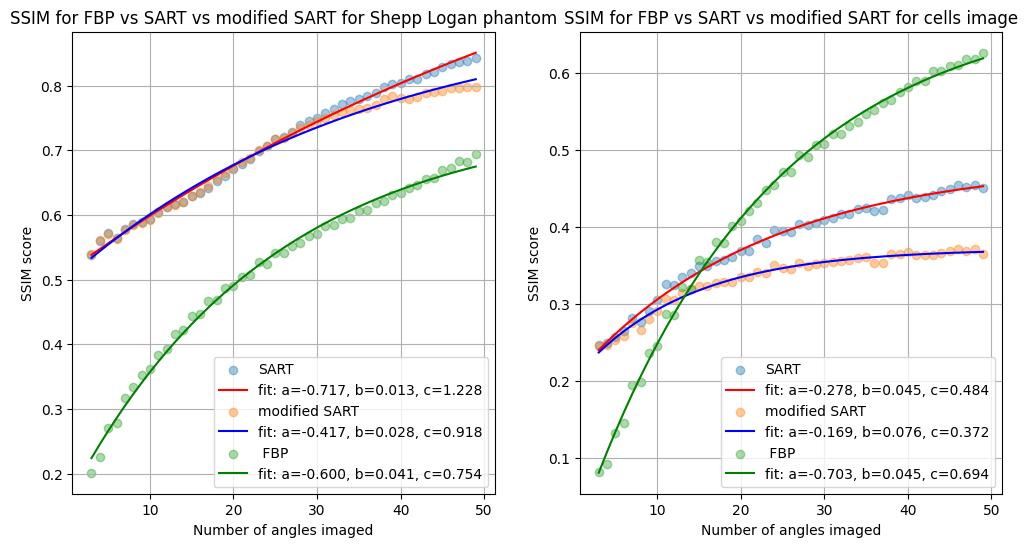

In [ ]:
phantom = shepp_logan_phantom()
# downsampling shepp logan phantom image
phantom = resize(
    phantom, (phantom.shape[0] // 2, phantom.shape[1] // 2), anti_aliasing=True
)
cells = io.imread("images/cells.tif")[32, :, :]
# downsampling cells image
cells = resize(cells, (cells.shape[0] // 2, cells.shape[1] // 2), anti_aliasing=True)

num_desired_slices = np.arange(3, 50, step=1)
ssim_fbp_phantom = []
ssim_sart_phantom = []
ssim_modified_sart_phantom = []
ssim_fbp_cells = []
ssim_sart_cells = []
ssim_modified_sart_cells = []
for i in num_desired_slices:
    # calculate phantom error
    sparse_sinogram_phantom = generate_sparse_sinogram(phantom, i)
    reconstruction_fbp_phantom = iradon(sparse_sinogram_phantom)
    ssim_fbp_phantom.append(calculate_ssim(phantom, reconstruction_fbp_phantom))
    reconstruction_sart_phantom = iradon_sart(sparse_sinogram_phantom)
    ssim_sart_phantom.append(calculate_ssim(phantom, reconstruction_sart_phantom))
    reconstruction_modified_sart_phantom = modified_sart_plus_tv(
        sparse_sinogram_phantom, weight=0.01
    )
    ssim_modified_sart_phantom.append(
        calculate_ssim(phantom, reconstruction_modified_sart_phantom)
    )

    # calculate cells error
    sparse_sinogram_cells = generate_sparse_sinogram(cells, i)
    reconstruction_fbp_cells = iradon(sparse_sinogram_cells)
    ssim_fbp_cells.append(calculate_ssim(cells, reconstruction_fbp_cells))
    reconstruction_sart_cells = iradon_sart(sparse_sinogram_cells)
    ssim_sart_cells.append(calculate_ssim(cells, reconstruction_sart_cells))
    reconstruction_modified_sart_cells = modified_sart_plus_tv(
        sparse_sinogram_cells, weight=0.01
    )
    ssim_modified_sart_cells.append(
        calculate_ssim(cells, reconstruction_modified_sart_cells)
    )


# curve fitting with expontential function
def func(x, a, b, c):
    return a * np.exp(-b * x) + c


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.set_title("SSIM for FBP vs SART vs modified SART for Shepp Logan phantom")
ax1.set_xlabel("Number of angles imaged")
ax1.set_ylabel("SSIM score")
ax1.grid()

# plot SART SSIM vals
ax1.scatter(num_desired_slices, ssim_sart_phantom, label="SART", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, ssim_sart_phantom, p0=[-1, 0.5, 1])
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="red",
)

# plot modified SART SSIM vals
ax1.scatter(
    num_desired_slices, ssim_modified_sart_phantom, label="modified SART", alpha=0.4
)
popt, pcov = curve_fit(
    func, num_desired_slices, ssim_modified_sart_phantom, p0=[-1, 0.5, 1]
)
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="blue",
)

ax1.scatter(num_desired_slices, ssim_fbp_phantom, label=" FBP", alpha=0.4)

popt, pcov = curve_fit(func, num_desired_slices, ssim_fbp_phantom, p0=[-1, 0.5, 1])
ax1.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="green",
)

ax2.set_title("SSIM for FBP vs SART vs modified SART for cells image")
ax2.set_xlabel("Number of angles imaged")
ax2.set_ylabel("SSIM score")
ax2.grid()

# plot SART SSIM vals
ax2.scatter(num_desired_slices, ssim_sart_cells, label="SART", alpha=0.4)
popt, pcov = curve_fit(func, num_desired_slices, ssim_sart_cells, p0=[-1, 0.5, 1])
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="red",
)

# plot modified SART SSIM vals
ax2.scatter(
    num_desired_slices, ssim_modified_sart_cells, label="modified SART", alpha=0.4
)
popt, pcov = curve_fit(
    func, num_desired_slices, ssim_modified_sart_cells, p0=[-1, 0.5, 1]
)
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="blue",
)

ax2.scatter(num_desired_slices, ssim_fbp_cells, label=" FBP", alpha=0.4)

popt, pcov = curve_fit(func, num_desired_slices, ssim_fbp_cells, p0=[-1, 0.5, 1])
ax2.plot(
    num_desired_slices,
    func(num_desired_slices, *popt),
    "r-",
    label="fit: a=%5.3f, b=%5.3f, c=%5.3f" % tuple(popt),
    color="green",
)

ax1.legend()
ax2.legend()
plt.show()